# Clase 6 · Carteras de mínimo riesgo y frontera eficiente de Markowitz

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prof-rodolfo-medina/modelizacion-derivados-carteras/blob/main/sesiones/semana-06/clase-06-carteras-minimo-riesgo-markowitz.ipynb)

**Semana 6 (07–11/12/2026) · Temas 8 y 9 · 60 min**

Objetivos:
1. Resolver con multiplicadores de Lagrange una minimización cuadrática con restricciones lineales.
2. Calcular la cartera de mínimo riesgo $w^*=\mathbf 1C^{-1}/(\mathbf 1C^{-1}\mathbf 1^\top)$.
3. Trazar la frontera eficiente y la «bala» de Markowitz con datos.

In [1]:
# Configuración: funciona en local (repositorio clonado) y en Google Colab
import sys, subprocess, pathlib
try:
    import mvdc
except ImportError:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "git+https://github.com/prof-rodolfo-medina/modelizacion-derivados-carteras.git"], check=True)
    else:
        for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
            if (base / "src" / "mvdc").exists():
                sys.path.insert(0, str(base / "src"))
                break
    import mvdc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("mvdc", mvdc.__version__)

mvdc 2026.11


## 1. Tema 8 — Lagrange (Ejemplo 1)

$$\min\; xAx^\top \quad \text{s.a.}\quad Bx^\top=b,\qquad
\lambda^*=2b^\top(BA^{-1}B^\top)^{-1},\quad x^*=\tfrac12\lambda^*BA^{-1}$$

In [2]:
from mvdc import portfolio as pf

A = np.diag([2, 1, 3]); B = [[1, 1, 1], [5, 10, 15]]
x, lam = pf.lagrange_quadratic(A, B, [14, 150])
print("x* =", x.round(6), "  λ* =", lam.round(6), "  riesgo mínimo =", x @ A @ x)

# Interpretación de λ*: sensibilidad del riesgo mínimo a cada restricción
for b_nuevo, etiqueta in [([15, 150], "invertir 1 u.m. más"), ([14, 145], "exigir rentabilidad 145")]:
    x2, _ = pf.lagrange_quadratic(A, B, b_nuevo)
    print(f"{etiqueta:25s}: ΔR real = {x2 @ A @ x2 - x @ A @ x:+.3f}   aprox. λ*·Δb = {lam @ (np.array(b_nuevo) - [14, 150]):+.3f}")

x* = [2. 8. 4.]   λ* = [0.  1.6]   riesgo mínimo = 120.00000000000051
invertir 1 u.m. más      : ΔR real = +5.000   aprox. λ*·Δb = +0.000
exigir rentabilidad 145  : ΔR real = -6.778   aprox. λ*·Δb = -8.000


## 2. Tema 9 — Cartera de mínimo riesgo (Ejemplo 1)

In [3]:
m = np.array([0.3, 0.2, 0.5])
C = pf.cov_from_corr([0.15, 0.02, 0.3], [[1, -0.07, 0.02], [-0.07, 1, 0.2], [0.02, 0.2, 1]])
w = pf.min_variance_weights(C)
mu_w, s_w = pf.portfolio_stats(w, m, C)
print("w* =", w.round(6))
print(f"μ* = {mu_w:.6f}   σ*² = {s_w**2:.7f}   σ* = {s_w:.5f}")

w* = [ 0.02628   0.982904 -0.009183]
μ* = 0.199873   σ*² = 0.0003766   σ* = 0.01941


> Observa que los pesos **no dependen de $m$**, solo de $C$. Hay una venta en corto
($w_3<0$): el problema (P-I) no impone $w_i\ge 0$.

## 3. Frontera eficiente con rendimiento prefijado (Teorema 3)

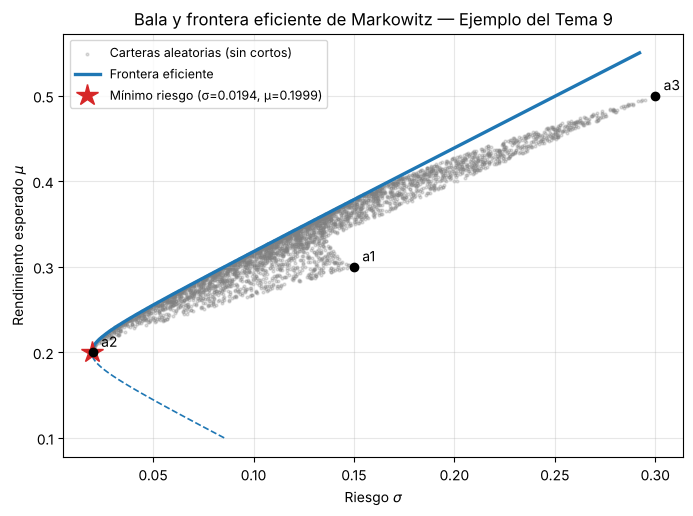

In [4]:
ax = pf.plot_frontier(m, C, mu_range=(0.1, 0.55), asset_labels=["a1", "a2", "a3"])
ax.set_title("Bala y frontera eficiente de Markowitz — Ejemplo del Tema 9");

In [5]:
# Los pesos de mínimo riesgo son lineales en μ: comprobación
mus = np.linspace(0.15, 0.45, 7)
_, _, W = pf.efficient_frontier(m, C, mus)
pd.DataFrame(W, index=pd.Index(mus.round(3), name="μ objetivo"), columns=["w1", "w2", "w3"]).round(4)

,w1,w2,w3
μ objetivo,,,
0.15,-0.1204,1.2469,-0.1265
0.20,0.0267,0.9822,-0.0089
0.25,0.1737,0.7175,0.1088
0.30,0.3208,0.4528,0.2264
0.35,0.4679,0.1881,0.3440
0.40,0.6149,-0.0766,0.4617
0.45,0.7620,-0.3413,0.5793


## 4. Con datos: 5 activos simulados (2 años, diarios) — mismo flujo que la Actividad 2

In [6]:
precios = mvdc.datos.cargar("cartera_simulada.csv")
R = pf.log_returns(precios)
m5, C5 = pf.mean_cov(R, periods_per_year=252)        # anualizados
display(pd.DataFrame({"μ anual": m5, "σ anual": np.sqrt(np.diag(C5))}, index=precios.columns).round(4))
display(pd.DataFrame(np.corrcoef(R, rowvar=False), index=precios.columns, columns=precios.columns).round(2))

,μ anual,σ anual
ALFA,0.1055,0.2554
BETA,0.0598,0.1734
GAMMA,0.0799,0.3603
DELTA,0.0538,0.1192
OMEGA,0.1059,0.3025


,ALFA,BETA,GAMMA,DELTA,OMEGA
ALFA,1.00,0.46,0.39,0.11,0.37
BETA,0.46,1.00,0.25,0.20,0.36
GAMMA,0.39,0.25,1.00,-0.12,0.43
DELTA,0.11,0.20,-0.12,1.00,0.06
OMEGA,0.37,0.36,0.43,0.06,1.00


{'ALFA': 0.0182, 'BETA': 0.19, 'GAMMA': 0.0757, 'DELTA': 0.7016, 'OMEGA': 0.0145}


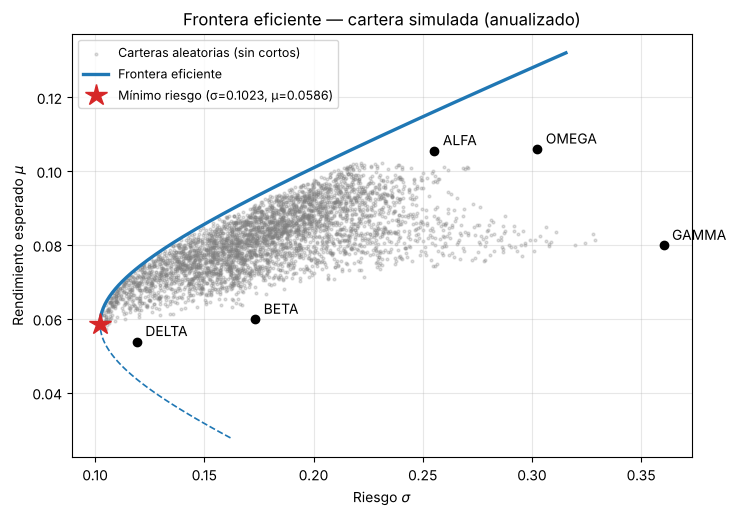

In [7]:
w5 = pf.min_variance_weights(C5)
print(pd.Series(w5, index=precios.columns).round(4).to_dict())
ax = pf.plot_frontier(m5, C5, asset_labels=list(precios.columns))
ax.set_title("Frontera eficiente — cartera simulada (anualizado)");

## 5. Ejercicio en clase

1. Repite la cartera de mínimo riesgo **sin ventas en corto** usando `scipy.optimize.minimize`
   con `bounds=[(0, 1)]*n`. ¿Cambia la solución? ¿Por qué?
2. ¿Qué tan estables son los pesos? Estima $C$ con solo el primer año de datos y compara.

In [8]:
# Tu código aquí
from scipy.optimize import minimize

> **Recordatorio:** la Actividad 2 se entrega el **lunes 14/12/2026 a las 23:59**.